In [13]:
import sys
from pathlib import Path

# Add CLAUDE/src to path — works when notebook is run from CLAUDE/notebooks/
_here = Path.cwd()
while not (_here / 'datasets').exists() and _here != _here.parent:
    _here = _here.parent
sys.path.insert(0, str(_here / 'CLAUDE' / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "axes.labelsize": 11,
    "font.size": 11,
    "figure.dpi": 120,
})

from data_loader import load_mat, load_characters_with_imdb, load_model_data
from prepare_training_data import build_story_features

# Training Data Exploration

This notebook explores the story-level training dataset built in `CLAUDE/src/prepare_training_data.py`.

**The approach:** instead of using discrete archetype labels (like `df_model.csv`), we work directly with the continuous SVD archetype space — the same representation used in the KS analysis. For each story, we aggregate its characters' scores on the 6 named framework axes into a mean and std across the cast.

**The 6 axes and their sign convention:**

| Column prefix | Left pole (positive score) | Right pole (negative score) |
|---|---|---|
| `fool_hero` | Fool | Hero |
| `angel_demon` | Angel | Demon |
| `trad_adventurer` | Traditionalist | Adventurer |
| `lone_wolf_diva` | Lone Wolf | Diva |
| `outcast_soph` | Outcast | Sophisticate |
| `brute_geek` | Brute | Geek |

A story with a high positive `fool_hero_mean` has a cast that leans Fool-like on average. A strongly negative value means the cast leans Hero-like.

## 1. Load Data

In [14]:
# Load once and reuse — the .mat file is 70 MB
mat        = load_mat()
chars_imdb = load_characters_with_imdb()

df = build_story_features(mat, chars_imdb)

print(f"Shape: {df.shape}  ({df.shape[0]} stories × {df.shape[1]-1} features + label)")
print(f"\nColumns:\n{list(df.columns)}")

Shape: (327, 14)  (327 stories × 13 features + label)

Columns:
['fool_hero_mean', 'fool_hero_std', 'angel_demon_mean', 'angel_demon_std', 'trad_adventurer_mean', 'trad_adventurer_std', 'lone_wolf_diva_mean', 'lone_wolf_diva_std', 'outcast_soph_mean', 'outcast_soph_std', 'brute_geek_mean', 'brute_geek_std', 'cast_size', 'is_comedy']


In [15]:
df.head(10)

,fool_hero_mean,fool_hero_std,angel_demon_mean,angel_demon_std,trad_adventurer_mean,trad_adventurer_std,lone_wolf_diva_mean,lone_wolf_diva_std,outcast_soph_mean,outcast_soph_std,brute_geek_mean,brute_geek_std,cast_size,is_comedy
story_name,,,,,,,,,,,,,,
(500) Days of Summer,8.353373,12.346157,-7.509349,6.439074,13.161957,19.002881,11.691623,9.962875,-11.954536,21.885571,8.717333,2.582246,2,1
10 Things I Hate About You,14.097583,23.374889,9.354443,31.610384,8.895335,24.075384,11.150856,27.514599,-5.885553,12.538668,-5.884582,16.216885,6,1
30 Rock,4.075425,25.237444,15.433939,39.076527,14.850955,34.311745,18.776029,14.310733,-11.492258,23.576287,-5.972302,8.732777,6,1
8 Mile,33.487735,0.000000,18.474906,0.000000,23.600837,0.000000,-23.653452,0.000000,-15.241622,0.000000,4.840814,0.000000,1,0
A Nightmare on Elm Street,14.259898,12.271795,15.068914,29.816788,0.390879,26.960561,5.550057,11.617184,-11.473695,5.731074,-7.737380,13.663728,5,0
A Series of Unfortunate Events,37.294823,31.800358,3.632574,54.001095,-2.139105,13.041584,2.745035,4.849898,-10.481052,8.611981,16.124795,5.170841,3,1
A Star Is Born,16.504863,13.921006,1.235229,21.970246,27.318987,3.920331,-7.981630,5.684261,-11.096272,7.850583,3.498290,5.756921,2,0
A Tale of Two Cities,18.615762,8.311955,-14.708407,18.432612,4.068556,7.534016,8.898924,15.761972,-6.054668,8.891179,0.812101,8.296673,3,0
Adventures of Huckleberry Finn,15.375274,11.681078,-16.051131,25.750793,27.398955,23.514573,-18.980683,1.592711,-16.836856,1.954977,-8.795055,1.353283,2,0


In [16]:
df.describe().round(2)

,fool_hero_mean,fool_hero_std,angel_demon_mean,angel_demon_std,trad_adventurer_mean,trad_adventurer_std,lone_wolf_diva_mean,lone_wolf_diva_std,outcast_soph_mean,outcast_soph_std,brute_geek_mean,brute_geek_std,cast_size,is_comedy
count,327.00,327.00,327.00,327.00,327.00,327.00,327.00,327.00,327.00,327.00,327.00,327.00,327.00,327.00
mean,24.78,16.34,1.48,24.31,9.04,19.76,4.14,11.71,-7.07,10.64,-0.46,9.84,5.83,0.36
std,13.66,7.59,13.88,11.37,11.59,9.79,9.30,6.14,6.95,4.94,7.06,5.22,3.84,0.48
min,-13.19,0.00,-34.19,0.00,-21.69,0.00,-35.49,0.00,-27.72,0.00,-22.78,0.00,1.00,0.00
25%,15.56,11.24,-8.66,17.83,0.49,14.02,-0.97,7.74,-11.92,7.63,-4.96,6.17,3.00,0.00
50%,24.81,16.47,1.24,24.66,7.95,20.12,4.20,11.58,-6.98,10.99,-1.15,9.44,6.00,0.00
75%,34.16,21.52,11.55,31.94,17.03,26.74,10.64,15.68,-2.95,14.09,3.47,13.20,6.00,1.00
max,64.43,33.05,47.72,61.66,47.80,45.61,25.36,27.51,12.54,27.28,25.09,35.92,30.00,1.00


## 2. Class Balance

In [17]:
counts = df['is_comedy'].value_counts().rename({1: 'Comedy', 0: 'Drama'})
print(counts.to_string())
print(f"\nRatio  comedy:drama = 1:{counts['Drama']/counts['Comedy']:.1f}")
print(f"Any NaN: {df.isna().any().any()}")

is_comedy
Drama     210
Comedy    117

Ratio  comedy:drama = 1:1.8
Any NaN: False


## 3. What Do the Numbers Mean?

A few concrete stories to ground the feature values before looking at distributions. 

The scale is raw SVD magnitude (unnormalized), so the absolute values aren't directly interpretable — what matters is the direction (sign) and relative differences between stories and genres.

In [18]:
# A handful of recognisable stories — mix of comedies and dramas
stories_of_interest = [
    '30 Rock', 'Arrested Development', 'Seinfeld',
    'Breaking Bad', 'The Godfather', 'Schindler\'s List',
    'The Office', 'Parks and Recreation',
]

sample = df[df.index.isin(stories_of_interest)].copy()
sample.insert(0, 'genre', sample['is_comedy'].map({1: 'Comedy', 0: 'Drama'}))
sample = sample.drop(columns='is_comedy')
sample.round(1)

,genre,fool_hero_mean,fool_hero_std,angel_demon_mean,angel_demon_std,trad_adventurer_mean,trad_adventurer_std,lone_wolf_diva_mean,lone_wolf_diva_std,outcast_soph_mean,outcast_soph_std,brute_geek_mean,brute_geek_std,cast_size
story_name,,,,,,,,,,,,,,
30 Rock,Comedy,4.1,25.2,15.4,39.1,14.9,34.3,18.8,14.3,-11.5,23.6,-6.0,8.7,6
Arrested Development,Comedy,-7.5,24.8,22.3,39.9,14.4,25.2,19.1,14.7,-15.0,19.2,3.5,10.0,10
Breaking Bad,Drama,23.2,24.2,16.8,17.8,0.0,25.2,0.8,18.7,-12.7,12.0,-0.9,17.0,10
Parks and Recreation,Comedy,22.0,24.5,-10.7,34.4,8.9,31.5,9.8,25.8,-3.1,15.3,-4.8,14.1,10
Seinfeld,Comedy,4.5,16.5,15.8,12.9,10.5,32.2,16.7,9.0,-15.2,14.1,-8.7,13.2,6
The Godfather,Drama,27.0,28.9,12.7,19.4,-9.3,18.9,1.6,6.8,-2.2,12.0,-9.8,11.2,6
The Office,Drama,2.0,24.9,10.7,37.4,11.0,31.1,13.8,18.3,-9.5,11.5,-5.8,6.5,15


In [19]:
# Genre-level means — the aggregate signal the classifier will work with
mean_features = (df.drop(columns='is_comedy')
                   .groupby(df['is_comedy'].map({1: 'Comedy', 0: 'Drama'}))
                   .mean()
                   .round(2))

print("Mean feature values by genre:")
mean_features

Mean feature values by genre:


,fool_hero_mean,fool_hero_std,angel_demon_mean,angel_demon_std,trad_adventurer_mean,trad_adventurer_std,lone_wolf_diva_mean,lone_wolf_diva_std,outcast_soph_mean,outcast_soph_std,brute_geek_mean,brute_geek_std,cast_size
is_comedy,,,,,,,,,,,,,
Comedy,20.19,16.88,0.55,25.30,14.12,21.82,6.2,12.12,-7.18,11.45,-0.79,9.80,5.28
Drama,27.34,16.03,2.00,23.76,6.21,18.61,3.0,11.48,-7.01,10.19,-0.28,9.86,6.14


## 4. Feature Distributions by Genre

Box plots for each axis, split by Comedy (orange) and Drama (blue). Top row: mean cast score. Bottom row: std (cast diversity).

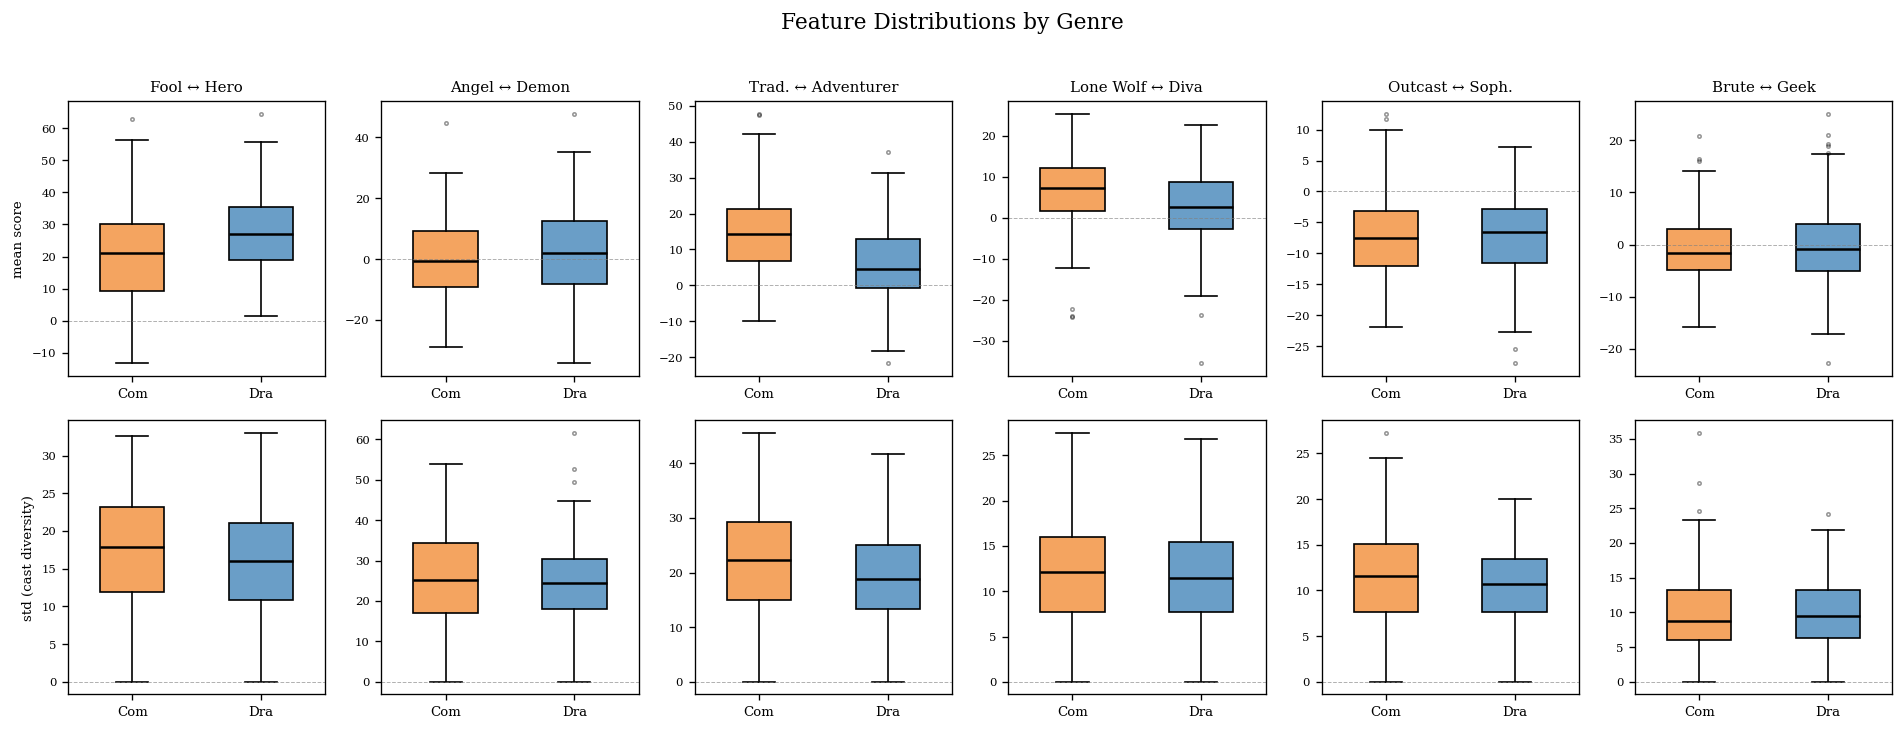

In [20]:
axis_prefixes = ['fool_hero', 'angel_demon', 'trad_adventurer',
                 'lone_wolf_diva', 'outcast_soph', 'brute_geek']

axis_labels = [
    'Fool ↔ Hero', 'Angel ↔ Demon', 'Trad. ↔ Adventurer',
    'Lone Wolf ↔ Diva', 'Outcast ↔ Soph.', 'Brute ↔ Geek'
]

comedy = df[df['is_comedy'] == 1]
drama  = df[df['is_comedy'] == 0]

fig, axes = plt.subplots(2, 6, figsize=(16, 6), sharey=False)
fig.suptitle('Feature Distributions by Genre', fontsize=13, y=1.01)

for col, (prefix, label) in enumerate(zip(axis_prefixes, axis_labels)):
    for row, stat in enumerate(['mean', 'std']):
        ax  = axes[row, col]
        col_name = f"{prefix}_{stat}"

        data_comedy = comedy[col_name].values
        data_drama  = drama[col_name].values

        bp = ax.boxplot(
            [data_comedy, data_drama],
            patch_artist=True,
            widths=0.5,
            medianprops=dict(color='black', linewidth=1.5),
            whiskerprops=dict(linewidth=1),
            capprops=dict(linewidth=1),
            flierprops=dict(marker='o', markersize=2, alpha=0.4),
        )

        bp['boxes'][0].set_facecolor('#F4A460')   # comedy — sandy brown
        bp['boxes'][1].set_facecolor('#6A9EC7')   # drama  — steel blue

        ax.set_xticks([1, 2])
        ax.set_xticklabels(['Com', 'Dra'], fontsize=8)
        ax.tick_params(axis='y', labelsize=7)
        ax.axhline(0, color='grey', linewidth=0.6, linestyle='--', alpha=0.6)

        if row == 0:
            ax.set_title(label, fontsize=9)
        if col == 0:
            ax.set_ylabel('mean score' if row == 0 else 'std (cast diversity)', fontsize=8)

plt.tight_layout()
plt.show()

## 5. How Separated Are the Genres? (KS Tests)

Run a KS test on each feature to quantify how much distributional separation exists between comedy and drama at the story level. This mirrors what the original notebook did at the character level — now we can see if the signal survives aggregation to stories.

In [21]:
from scipy.stats import ks_2samp

feature_cols = [c for c in df.columns if c != 'is_comedy']
results = []

for col in feature_cols:
    stat, pval = ks_2samp(comedy[col].values, drama[col].values)
    results.append({'feature': col, 'ks_stat': stat, 'p_value': pval})

ks_df = (pd.DataFrame(results)
           .sort_values('ks_stat', ascending=False)
           .reset_index(drop=True))

ks_df['significant'] = ks_df['p_value'] < 0.05
ks_df.round(4)

,feature,ks_stat,p_value,significant
0,trad_adventurer_mean,0.3368,0.0000,True
1,fool_hero_mean,0.2520,0.0001,True
2,lone_wolf_diva_mean,0.2354,0.0004,True
3,trad_adventurer_std,0.1700,0.0224,True
4,angel_demon_mean,0.1353,0.1141,False
5,angel_demon_std,0.1322,0.1294,False
6,outcast_soph_std,0.1314,0.1339,False
7,brute_geek_mean,0.1048,0.3510,False
8,cast_size,0.0985,0.4248,False
9,fool_hero_std,0.0957,0.4608,False


## 6. Compare to Baseline (df_model.csv)

The old approach (`df_model.csv`) used proportions of characters assigned to each of 6 base archetype *labels* — a coarser, discrete representation. Here we put both datasets side by side to see what changed.

In [22]:
df_baseline = load_model_data()

print("=== New approach (continuous SVD scores) ===")
print(f"Shape: {df.shape}")
print(f"Features: {[c for c in df.columns if c != 'is_comedy']}\n")

print("=== Baseline (df_model.csv — archetype proportions) ===")
print(f"Shape: {df_baseline.shape}")
print(f"Features: {[c for c in df_baseline.columns if c != 'is_comedy']}")

=== New approach (continuous SVD scores) ===
Shape: (327, 14)
Features: ['fool_hero_mean', 'fool_hero_std', 'angel_demon_mean', 'angel_demon_std', 'trad_adventurer_mean', 'trad_adventurer_std', 'lone_wolf_diva_mean', 'lone_wolf_diva_std', 'outcast_soph_mean', 'outcast_soph_std', 'brute_geek_mean', 'brute_geek_std', 'cast_size']

=== Baseline (df_model.csv — archetype proportions) ===
Shape: (283, 7)
Features: ['Adventurer', 'Angel', 'Demon', 'Fool', 'Hero', 'Traditionalist']


In [23]:
# KS stats for baseline features — lets us compare signal strength directly
baseline_comedy = df_baseline[df_baseline['is_comedy'] == 1]
baseline_drama  = df_baseline[df_baseline['is_comedy'] == 0]
baseline_feat   = [c for c in df_baseline.columns if c != 'is_comedy']

baseline_ks = []
for col in baseline_feat:
    stat, pval = ks_2samp(baseline_comedy[col].values, baseline_drama[col].values)
    baseline_ks.append({'feature': col, 'ks_stat': stat, 'p_value': pval})

baseline_ks_df = (pd.DataFrame(baseline_ks)
                    .sort_values('ks_stat', ascending=False)
                    .reset_index(drop=True))
baseline_ks_df['significant'] = baseline_ks_df['p_value'] < 0.05

print("Baseline KS stats (archetype proportions):")
print(baseline_ks_df.round(4).to_string(index=False))

print("\nNew approach KS stats (continuous SVD means, top 6):")
print(ks_df[ks_df['feature'].str.endswith('_mean')].round(4).to_string(index=False))

Baseline KS stats (archetype proportions):
       feature  ks_stat  p_value  significant
          Hero   0.2812   0.0001         True
          Fool   0.2101   0.0063         True
         Angel   0.1497   0.1043        False
         Demon   0.1406   0.1457        False
    Adventurer   0.1352   0.1771        False
Traditionalist   0.0274   1.0000        False

New approach KS stats (continuous SVD means, top 6):
             feature  ks_stat  p_value  significant
trad_adventurer_mean   0.3368   0.0000         True
      fool_hero_mean   0.2520   0.0001         True
 lone_wolf_diva_mean   0.2354   0.0004         True
    angel_demon_mean   0.1353   0.1141        False
     brute_geek_mean   0.1048   0.3510        False
   outcast_soph_mean   0.0851   0.6094        False


## 7. Cast Size Distribution

How many characters per story? This affects the reliability of the std feature — stories with 1–2 characters will have very low or zero std regardless of genre.

Cast size by genre:
           count  mean  std  min  25%  50%  75%   max
is_comedy                                            
Drama      210.0   6.1  4.2  1.0  3.0  6.0  9.0  30.0
Comedy     117.0   5.3  2.9  1.0  3.0  5.0  6.0  15.0

Stories with only 1 character: 10
Stories with 2 characters:     42


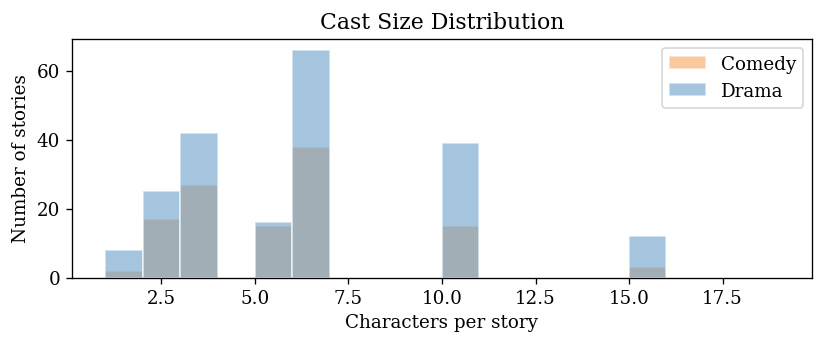

In [24]:
cast_sizes = (chars_imdb
              .groupby('story_name')['character_name']
              .count()
              .rename('cast_size'))

# Align to stories in df
cast_sizes = cast_sizes[cast_sizes.index.isin(df.index)]

summary = cast_sizes.groupby(df['is_comedy'].rename('is_comedy')).describe()
summary.index = summary.index.map({1: 'Comedy', 0: 'Drama'})
print("Cast size by genre:")
print(summary.round(1).to_string())

print(f"\nStories with only 1 character: {(cast_sizes == 1).sum()}")
print(f"Stories with 2 characters:     {(cast_sizes == 2).sum()}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(cast_sizes[df['is_comedy'] == 1], bins=range(1, 20), alpha=0.6,
        color='#F4A460', label='Comedy', edgecolor='white')
ax.hist(cast_sizes[df['is_comedy'] == 0], bins=range(1, 20), alpha=0.6,
        color='#6A9EC7', label='Drama', edgecolor='white')
ax.set_xlabel('Characters per story')
ax.set_ylabel('Number of stories')
ax.set_title('Cast Size Distribution')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. The Visual Argument: Why Prediction is Hard

Three views of the same problem: the signal is real, but the classes overlap substantially in feature space.

### 8a. Scatter Plot — Best Two Features

The two features with the strongest KS signal plotted against each other. If the classes were well-separated, you'd see two distinct clouds. What you'll see instead is the problem.

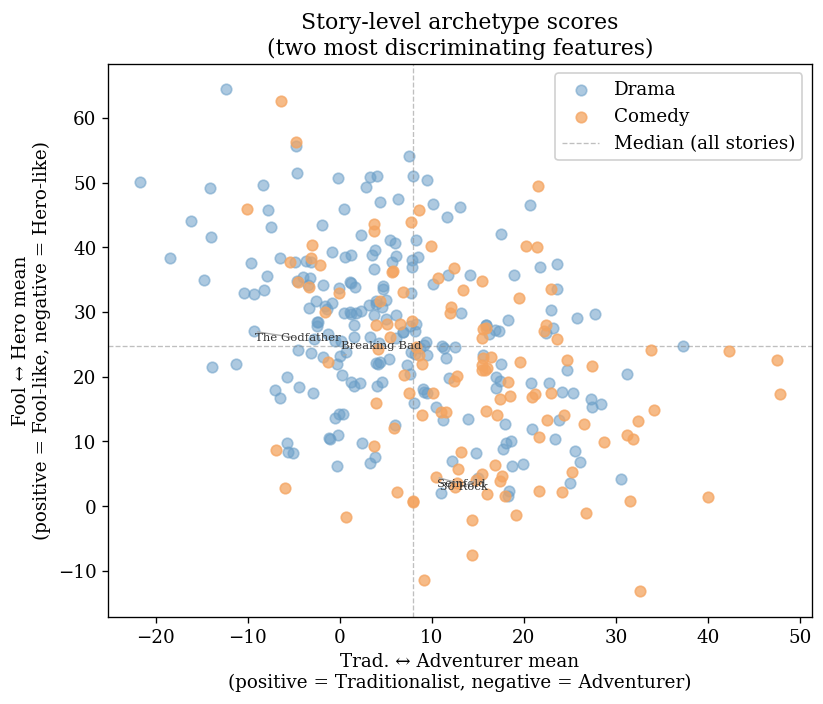

Stories per quadrant:
trad_pos  Trad+ / Fool+  Trad+ / Fool-  Trad- / Fool+  Trad- / Fool-
genre                                                               
Comedy               19             63             23             12
Drama                32             49             89             40


In [25]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    drama['trad_adventurer_mean'], drama['fool_hero_mean'],
    color='#6A9EC7', alpha=0.55, s=40, label='Drama', zorder=2
)
ax.scatter(
    comedy['trad_adventurer_mean'], comedy['fool_hero_mean'],
    color='#F4A460', alpha=0.75, s=40, label='Comedy', zorder=3
)

# Label a few recognisable stories
label_stories = {
    'Seinfeld': (0.1, -1.5), 'The Godfather': (0.1, -1.5),
    'Breaking Bad': (0.1, 1.2), '30 Rock': (-4, -1.5),
    'Schindler\'s List': (0.5, 0.5),
}
for story, (dx, dy) in label_stories.items():
    if story in df.index:
        x = df.loc[story, 'trad_adventurer_mean']
        y = df.loc[story, 'fool_hero_mean']
        ax.annotate(story, (x, y), (x + dx, y + dy),
                    fontsize=7, color='#333333',
                    arrowprops=dict(arrowstyle='-', color='#aaaaaa', lw=0.8))

ax.axvline(df['trad_adventurer_mean'].median(), color='grey',
           lw=0.8, ls='--', alpha=0.5, label='Median (all stories)')
ax.axhline(df['fool_hero_mean'].median(), color='grey', lw=0.8, ls='--', alpha=0.5)

ax.set_xlabel('Trad. ↔ Adventurer mean\n(positive = Traditionalist, negative = Adventurer)')
ax.set_ylabel('Fool ↔ Hero mean\n(positive = Fool-like, negative = Hero-like)')
ax.set_title('Story-level archetype scores\n(two most discriminating features)')
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.show()

# Print how many of each genre fall in each quadrant
q = pd.DataFrame({
    'trad_pos': df['trad_adventurer_mean'] > df['trad_adventurer_mean'].median(),
    'fool_pos': df['fool_hero_mean'] > df['fool_hero_mean'].median(),
    'genre': df['is_comedy'].map({1: 'Comedy', 0: 'Drama'})
})
print("Stories per quadrant:")
print(pd.crosstab(q['genre'],
                  q['trad_pos'].map({True:'Trad+', False:'Trad-'}).str.cat(
                  q['fool_pos'].map({True:'Fool+', False:'Fool-'}), sep=' / ')))

### 8b. KDE Density Plots — The 3 Significant Features

For each of the three features with p < 0.05, overlapping density curves show exactly where the distributions differ and how much they share.

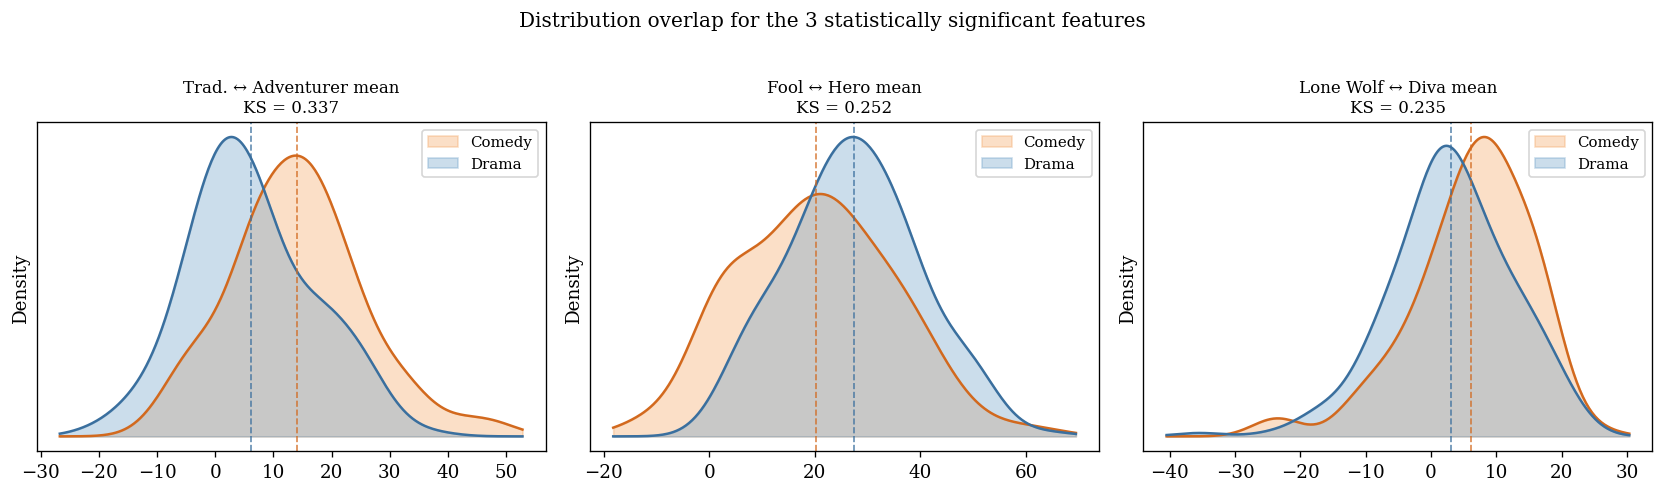

In [26]:
from scipy.stats import gaussian_kde

sig_features = ['trad_adventurer_mean', 'fool_hero_mean', 'lone_wolf_diva_mean']
sig_labels   = ['Trad. ↔ Adventurer mean', 'Fool ↔ Hero mean', 'Lone Wolf ↔ Diva mean']
sig_ks       = ks_df.set_index('feature').loc[sig_features, 'ks_stat'].round(3).values

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, feat, label, ks in zip(axes, sig_features, sig_labels, sig_ks):
    c_vals = comedy[feat].values
    d_vals = drama[feat].values
    x = np.linspace(min(c_vals.min(), d_vals.min()) - 5,
                    max(c_vals.max(), d_vals.max()) + 5, 300)

    kde_c = gaussian_kde(c_vals, bw_method=0.4)
    kde_d = gaussian_kde(d_vals, bw_method=0.4)

    ax.fill_between(x, kde_c(x), alpha=0.35, color='#F4A460', label='Comedy')
    ax.fill_between(x, kde_d(x), alpha=0.35, color='#6A9EC7', label='Drama')
    ax.plot(x, kde_c(x), color='#D2691E', lw=1.5)
    ax.plot(x, kde_d(x), color='#3A6F9E', lw=1.5)

    ax.axvline(c_vals.mean(), color='#D2691E', lw=1, ls='--', alpha=0.8)
    ax.axvline(d_vals.mean(), color='#3A6F9E', lw=1, ls='--', alpha=0.8)

    ax.set_title(f'{label}\nKS = {ks}', fontsize=10)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.set_yticks([])

plt.suptitle('Distribution overlap for the 3 statistically significant features',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 8c. Cross-Validated Accuracy

The practical bottom line: how well does a classifier actually do with these features? We test three models with stratified 5-fold CV. The majority-class baseline (always predict Drama) gives 64% accuracy — any model needs to beat that to be useful.

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
import warnings
warnings.filterwarnings('ignore')

feat_cols = [c for c in df.columns if c.endswith('_mean') or c.endswith('_std')]
X = df[feat_cols].values
y = df['is_comedy'].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Majority class (baseline)': Pipeline([
        ('clf', DummyClassifier(strategy='most_frequent'))
    ]),
    'Logistic Regression (L2)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, C=0.1))
    ]),
    'Random Forest': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                       max_depth=4, random_state=42))
    ]),
}

scoring = ['accuracy', 'roc_auc', 'f1']

print(f"{'Model':<30} {'Accuracy':>10} {'ROC-AUC':>10} {'F1':>10}")
print("-" * 64)

for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    acc = scores['test_accuracy'].mean()
    auc = scores['test_roc_auc'].mean()
    f1  = scores['test_f1'].mean()
    print(f"{name:<30} {acc:>10.3f} {auc:>10.3f} {f1:>10.3f}")

Model                            Accuracy    ROC-AUC         F1
----------------------------------------------------------------
Majority class (baseline)           0.642      0.500      0.000
Logistic Regression (L2)            0.685      0.711      0.614
Random Forest                       0.688      0.711      0.557
